# Analyse statistique des donnees olympiques

---

**Objectif** : Ce notebook constitue le volet *Maths pour la DataScience* de notre projet de data storytelling sur les Jeux Olympiques. Il vise a :

1. **Quantifier** la qualite et la quantite des donnees a l'aide de statistiques descriptives et inferentielles.
2. **Etablir des indicateurs** univaries et multivaries pour caracteriser les performances olympiques.
3. **Appliquer des methodes d'analyse** (tests d'hypotheses, intervalles de confiance, ACP) pour degager des structures latentes.

Les donnees couvrent l'ensemble des editions des Jeux Olympiques de 1896 a 2024, soit plus de 310 000 participations individuelles.

---

## 1. Imports et chargement des donnees

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, shapiro
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Configuration graphique ---
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})
sns.set_style("whitegrid")
PALETTE = sns.color_palette("Set2", 8)

print("Imports OK")

Imports OK


In [2]:
# --- Chargement des donnees ---
DATA_DIR = "../data/processed/"

athletes = pd.read_csv(DATA_DIR + "athletes_events.csv")
medals = pd.read_csv(DATA_DIR + "medal_counts.csv")
country_stats = pd.read_csv(DATA_DIR + "country_stats.csv")

print(f"athletes_events : {athletes.shape[0]:,} lignes x {athletes.shape[1]} colonnes")
print(f"medal_counts    : {medals.shape[0]:,} lignes x {medals.shape[1]} colonnes")
print(f"country_stats   : {country_stats.shape[0]:,} lignes x {country_stats.shape[1]} colonnes")

athletes_events : 310,612 lignes x 15 colonnes
medal_counts    : 1,748 lignes x 7 colonnes
country_stats   : 1,748 lignes x 5 colonnes


In [3]:
# Apercu rapide
athletes.head(3)

,Name,Sex,Age,Height,Weight,Team,NOC,Country,Games,Year,Season,City,Sport,Event,Medal
0,Jean-François Blanchy,M,26.0,185.0,79.0,NaN,FRA,France,1912 Summer Olympics,1912,Summer,Stockholm,Tennis,"Singles, Men (Olympic)",NaN
1,Jean-François Blanchy,M,26.0,185.0,79.0,Jean Montariol,FRA,France,1912 Summer Olympics,1912,Summer,Stockholm,Tennis,"Doubles, Men (Olympic)",NaN
2,Jean-François Blanchy,M,34.0,185.0,79.0,NaN,FRA,France,1920 Summer Olympics,1920,Summer,Antwerp,Tennis,"Singles, Men (Olympic)",NaN


---

## 2. Statistiques descriptives

Avant toute modelisation, il est indispensable de comprendre la distribution des variables numeriques cles.
Nous examinons ici les trois variables biometriques disponibles : **Age**, **Taille** (Height) et **Poids** (Weight).

In [4]:
# --- Statistiques descriptives de base ---
biometric_cols = ["Age", "Height", "Weight"]
athletes[biometric_cols].describe().round(2)

,Age,Height,Weight
count,305592.00,302165.00,301558.00
mean,25.71,175.53,70.79
std,5.94,9.82,13.10
min,11.00,127.00,25.00
25%,22.00,169.00,62.00
50%,25.00,176.00,71.00
75%,29.00,182.00,78.00
max,73.00,226.00,198.00


In [5]:
# --- Tableau enrichi avec moments d'ordre superieur ---
def detailed_stats(df, columns):
    """Compute a detailed descriptive statistics table."""
    records = []
    for col in columns:
        s = df[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        records.append({
            "Variable": col,
            "N valide": int(s.count()),
            "Moyenne": round(s.mean(), 2),
            "Mediane": round(s.median(), 2),
            "Ecart-type": round(s.std(), 2),
            "Min": round(s.min(), 2),
            "Max": round(s.max(), 2),
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(q3 - q1, 2),
            "Skewness": round(s.skew(), 3),
            "Kurtosis": round(s.kurtosis(), 3),
        })
    return pd.DataFrame(records).set_index("Variable")


desc_table = detailed_stats(athletes, biometric_cols)
desc_table

,N valide,Moyenne,Mediane,Ecart-type,Min,Max,Q1,Q3,IQR,Skewness,Kurtosis
Variable,,,,,,,,,,,
Age,305592,25.71,25.0,5.94,11.0,73.0,22.0,29.0,7.0,1.228,3.231
Height,302165,175.53,176.0,9.82,127.0,226.0,169.0,182.0,13.0,-0.028,0.372
Weight,301558,70.79,71.0,13.10,25.0,198.0,62.0,78.0,16.0,0.676,2.029


**Interpretation** :

- L'**age median** des athletes est d'environ 24-25 ans, avec une distribution legerement asymetrique a droite (skewness > 0), ce qui traduit la presence d'athletes veterants dans certaines disciplines (equitation, tir).
- La **taille** presente une distribution quasi-normale (kurtosis proche de 0), centree autour de 177 cm.
- Le **poids** est plus disperse (IQR plus large en proportion) et presente une asymetrie positive plus marquee, refletant les sports de force (halterophilie, judo poids lourds).

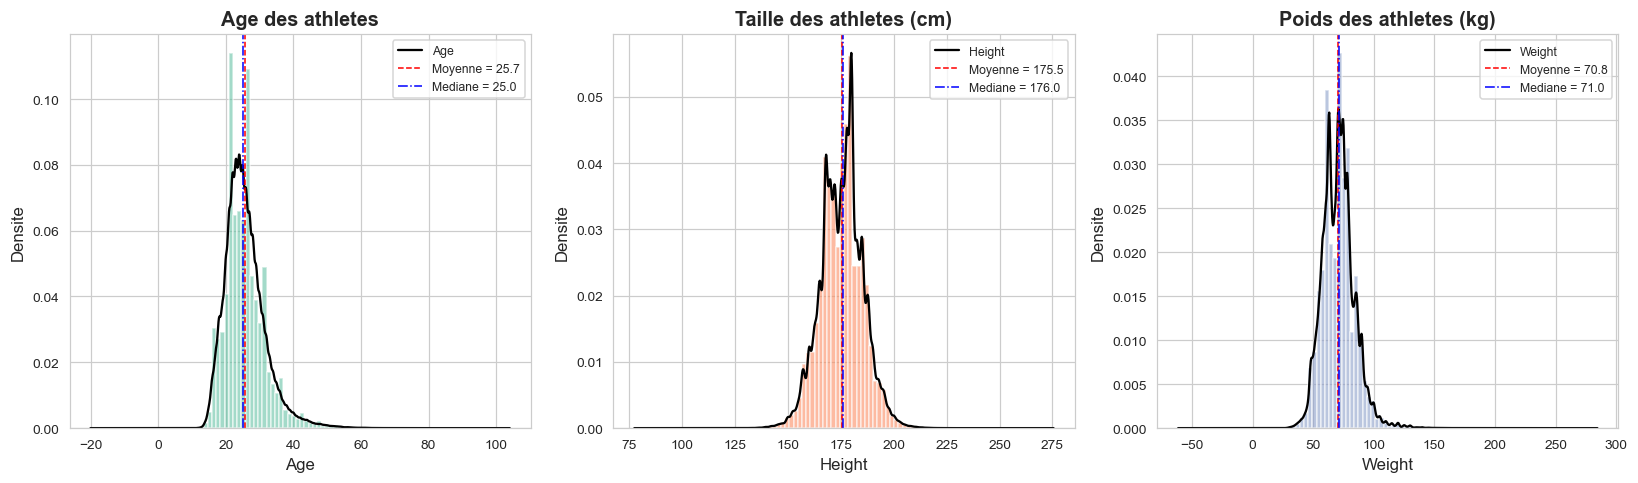

Figure 1 : Distributions des variables biometriques


In [6]:
# --- Histogrammes + KDE pour Age, Height, Weight ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

titles_fr = ["Age des athletes", "Taille des athletes (cm)", "Poids des athletes (kg)"]
colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

for ax, col, title, color in zip(axes, biometric_cols, titles_fr, colors):
    data = athletes[col].dropna()
    ax.hist(data, bins=50, density=True, alpha=0.6, color=color, edgecolor="white")
    data.plot.kde(ax=ax, color="black", linewidth=1.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Densite")
    ax.set_xlabel(col)
    # Add mean and median lines
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1, label=f"Moyenne = {data.mean():.1f}")
    ax.axvline(data.median(), color="blue", linestyle="-.", linewidth=1, label=f"Mediane = {data.median():.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/fig_histograms_biometrics.png", bbox_inches="tight")
plt.show()
print("Figure 1 : Distributions des variables biometriques")

In [7]:
# --- Statistiques par sexe ---
# Filtrer les valeurs valides de Sex (M et F uniquement)
athletes_mf = athletes[athletes["Sex"].isin(["M", "F"])].copy()

sex_stats = athletes_mf.groupby("Sex")[biometric_cols].agg(["mean", "median", "std", "count"]).round(2)
sex_stats.columns = [f"{col} ({stat})" for col, stat in sex_stats.columns]
sex_stats

,Age (mean),Age (median),Age (std),Age (count),Height (mean),Height (median),Height (std),Height (count),Weight (mean),Weight (median),Weight (std),Weight (count)
Sex,,,,,,,,,,,,
F,24.15,24.0,5.35,83403,167.84,168.0,8.40,83455,59.99,60.0,9.66,83428
M,26.15,25.0,5.47,199046,178.74,179.0,8.62,201386,75.28,74.0,11.72,201210


Sans surprise, les athletes masculins presentent en moyenne une taille et un poids superieurs.
L'ecart d'age moyen entre hommes et femmes est faible, ce qui suggere des carrieres de duree similaire.

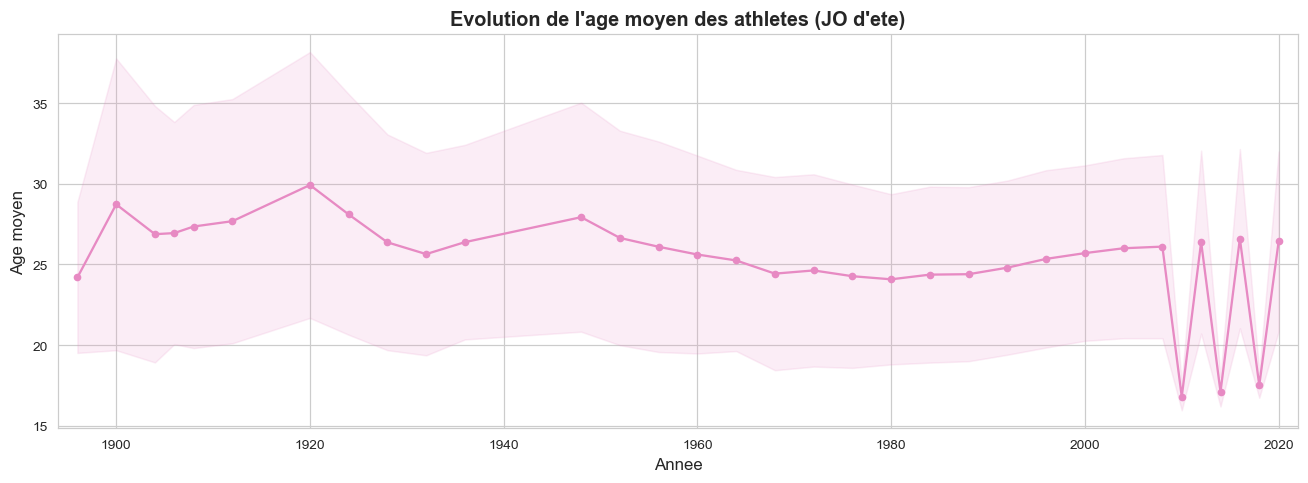

Figure 2 : Evolution de l'age moyen (bande = +/- 1 ecart-type)


In [8]:
# --- Evolution de l'age moyen au fil des editions ---
# On se concentre sur les JO d'ete (Summer) pour la lisibilite
summer = athletes[athletes["Season"] == "Summer"].copy()
age_by_year = summer.groupby("Year")["Age"].agg(["mean", "std"]).dropna()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(age_by_year.index, age_by_year["mean"], marker="o", markersize=4, color=PALETTE[3], linewidth=1.5)
ax.fill_between(
    age_by_year.index,
    age_by_year["mean"] - age_by_year["std"],
    age_by_year["mean"] + age_by_year["std"],
    alpha=0.15,
    color=PALETTE[3],
)
ax.set_title("Evolution de l'age moyen des athletes (JO d'ete)", fontweight="bold")
ax.set_xlabel("Annee")
ax.set_ylabel("Age moyen")
ax.set_xlim(age_by_year.index.min() - 2, age_by_year.index.max() + 2)
plt.tight_layout()
plt.savefig("../data/processed/fig_age_evolution.png", bbox_inches="tight")
plt.show()
print("Figure 2 : Evolution de l'age moyen (bande = +/- 1 ecart-type)")

L'age moyen des athletes a considerablement baisse entre les premieres editions (ou les participants etaient souvent des amateurs plus ages) et la periode moderne, avant de se stabiliser autour de 26 ans a partir des annees 1960.

---

## 3. Indicateurs univaries

Nous construisons ici des indicateurs permettant de caracteriser les performances olympiques selon une seule dimension a la fois.

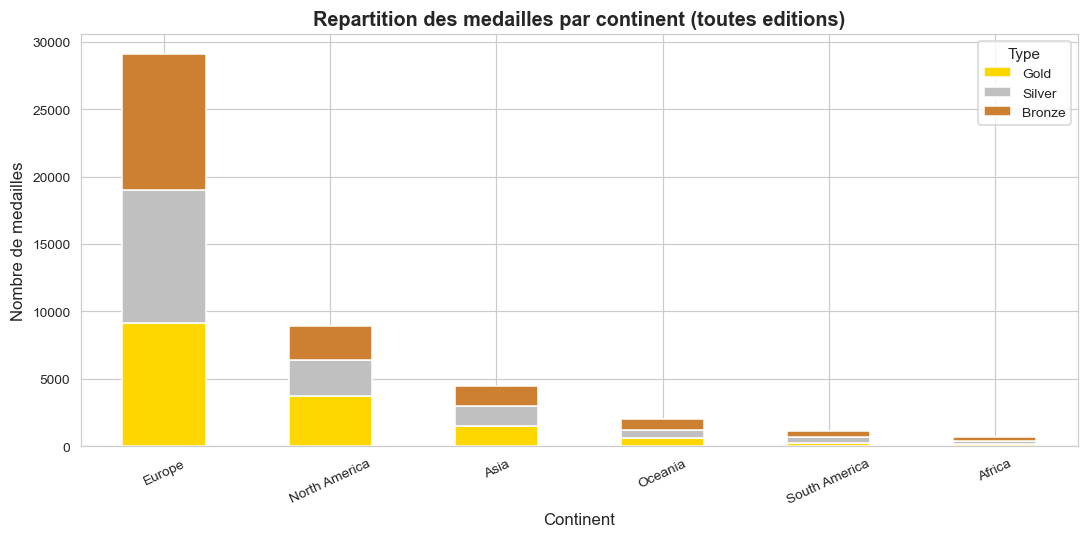

Figure 3 : Repartition des medailles par continent


In [9]:
# --- Distribution des medailles par continent ---
medals_with_continent = medals.merge(
    country_stats[["NOC", "Year", "Continent"]],
    on=["NOC", "Year"],
    how="left",
)

continent_medals = (
    medals_with_continent
    .dropna(subset=["Continent"])
    .groupby("Continent")[["Gold", "Silver", "Bronze"]]
    .sum()
    .sort_values("Gold", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
continent_medals.plot(kind="bar", stacked=True, ax=ax, color=["#FFD700", "#C0C0C0", "#CD7F32"])
ax.set_title("Repartition des medailles par continent (toutes editions)", fontweight="bold")
ax.set_xlabel("Continent")
ax.set_ylabel("Nombre de medailles")
ax.legend(title="Type")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("../data/processed/fig_medals_by_continent.png", bbox_inches="tight")
plt.show()
print("Figure 3 : Repartition des medailles par continent")

L'Europe domine historiquement le palmares olympique, concentrant a elle seule pres de deux tiers des medailles.
L'Amerique du Nord (essentiellement les Etats-Unis) arrive en deuxieme position, loin devant l'Asie.
L'Afrique et l'Amerique du Sud restent nettement sous-representees.

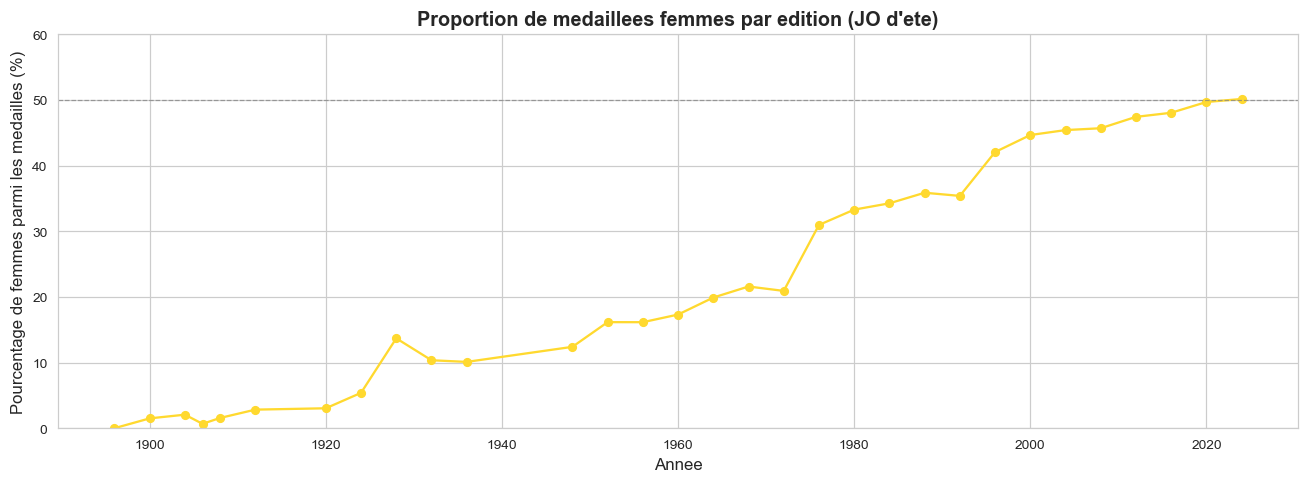

Figure 4 : Evolution de la proportion de medaillees femmes


In [10]:
# --- Proportion de medaillees femmes par edition ---
medalists = athletes[athletes["Medal"].notna()].copy()
medalists_mf = medalists[medalists["Sex"].isin(["M", "F"])].copy()

# On se concentre sur les JO d'ete
medalists_summer = medalists_mf[medalists_mf["Season"] == "Summer"]

female_ratio = (
    medalists_summer
    .groupby("Year")["Sex"]
    .apply(lambda x: (x == "F").mean() * 100)
)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(female_ratio.index, female_ratio.values, marker="o", markersize=5, color=PALETTE[5], linewidth=1.5)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("Proportion de medaillees femmes par edition (JO d'ete)", fontweight="bold")
ax.set_xlabel("Annee")
ax.set_ylabel("Pourcentage de femmes parmi les medailles (%)")
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig("../data/processed/fig_female_medalists_ratio.png", bbox_inches="tight")
plt.show()
print("Figure 4 : Evolution de la proportion de medaillees femmes")

La progression est spectaculaire : de 0% en 1896 (aucune femme n'etait autorisee) a pres de la parite dans les editions recentes.
Les Jeux de 2024 a Paris marquent un tournant historique en s'approchant du 50/50.

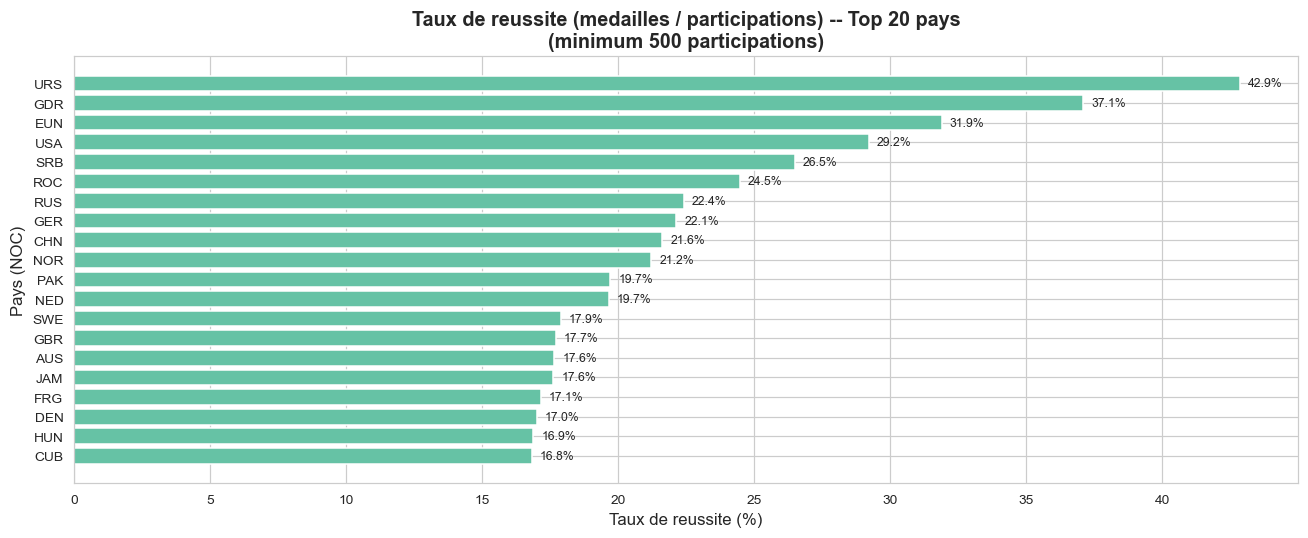

Figure 5 : Taux de reussite des 20 premiers pays


In [11]:
# --- Taux de reussite (medailles / participants) par pays -- top 20 ---
# Nombre de participations par pays (toutes editions confondues)
participations = athletes.groupby("NOC").size().rename("Participations")

# Nombre de medailles par pays
total_medals_by_noc = medalists.groupby("NOC").size().rename("Medals")

# Taux de reussite
success_rate = pd.concat([participations, total_medals_by_noc], axis=1).fillna(0)
success_rate["Taux_reussite"] = (success_rate["Medals"] / success_rate["Participations"] * 100).round(2)

# Filtrer les pays avec au moins 500 participations pour eviter les biais
success_rate_filtered = success_rate[success_rate["Participations"] >= 500].sort_values(
    "Taux_reussite", ascending=False
).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    success_rate_filtered.index[::-1],
    success_rate_filtered["Taux_reussite"].values[::-1],
    color=PALETTE[0],
    edgecolor="white",
)
ax.set_title("Taux de reussite (medailles / participations) -- Top 20 pays\n(minimum 500 participations)", fontweight="bold")
ax.set_xlabel("Taux de reussite (%)")
ax.set_ylabel("Pays (NOC)")
for i, (val, noc) in enumerate(zip(success_rate_filtered["Taux_reussite"].values[::-1], success_rate_filtered.index[::-1])):
    ax.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../data/processed/fig_success_rate_top20.png", bbox_inches="tight")
plt.show()
print("Figure 5 : Taux de reussite des 20 premiers pays")

Le taux de reussite permet de normaliser les performances en tenant compte du nombre de participants.
Certains pays avec moins de participations globales affichent des taux remarquablement eleves,
ce qui reflete une strategie de specialisation dans des disciplines a fort rendement en medailles.

---

## 4. Indicateurs multivaries

Nous explorons maintenant les relations entre plusieurs variables simultanement. La question centrale est : **quels facteurs structurels (population, nombre de participations) sont correles aux performances olympiques ?**

In [12]:
# --- Preparation du jeu de donnees fusionne ---
merged = medals.merge(country_stats, on=["NOC", "Year"], how="left", suffixes=("", "_cs"))

# Garder les colonnes utiles et supprimer les doublons de Country
if "Country_cs" in merged.columns:
    merged.drop(columns=["Country_cs"], inplace=True)

# Filtrer les lignes avec population connue pour l'analyse de correlation
merged_pop = merged.dropna(subset=["Population_million"]).copy()
print(f"Donnees avec population connue : {len(merged_pop)} lignes sur {len(merged)}")

Donnees avec population connue : 1178 lignes sur 1748


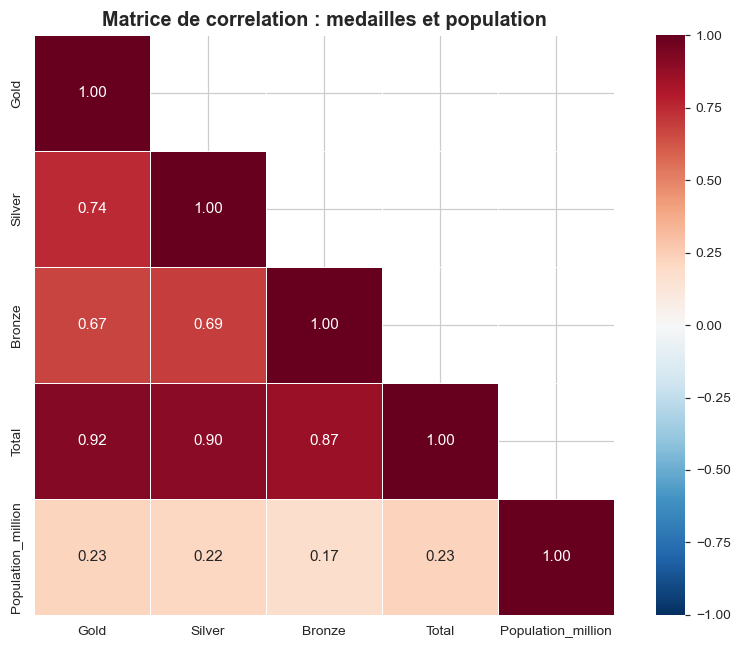

Figure 6 : Matrice de correlation


In [13]:
# --- Matrice de correlation ---
corr_cols = ["Gold", "Silver", "Bronze", "Total", "Population_million"]
corr_matrix = merged_pop[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1,
)
ax.set_title("Matrice de correlation : medailles et population", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_correlation_matrix.png", bbox_inches="tight")
plt.show()
print("Figure 6 : Matrice de correlation")

Les types de medailles (Gold, Silver, Bronze) sont tres fortement correles entre eux (r > 0.85),
ce qui est logique : un pays performant l'est generalement a tous les niveaux du podium.
La **population** montre une correlation positive moderee avec le total de medailles, suggerant que la taille du pays est un avantage, mais insuffisant a lui seul.

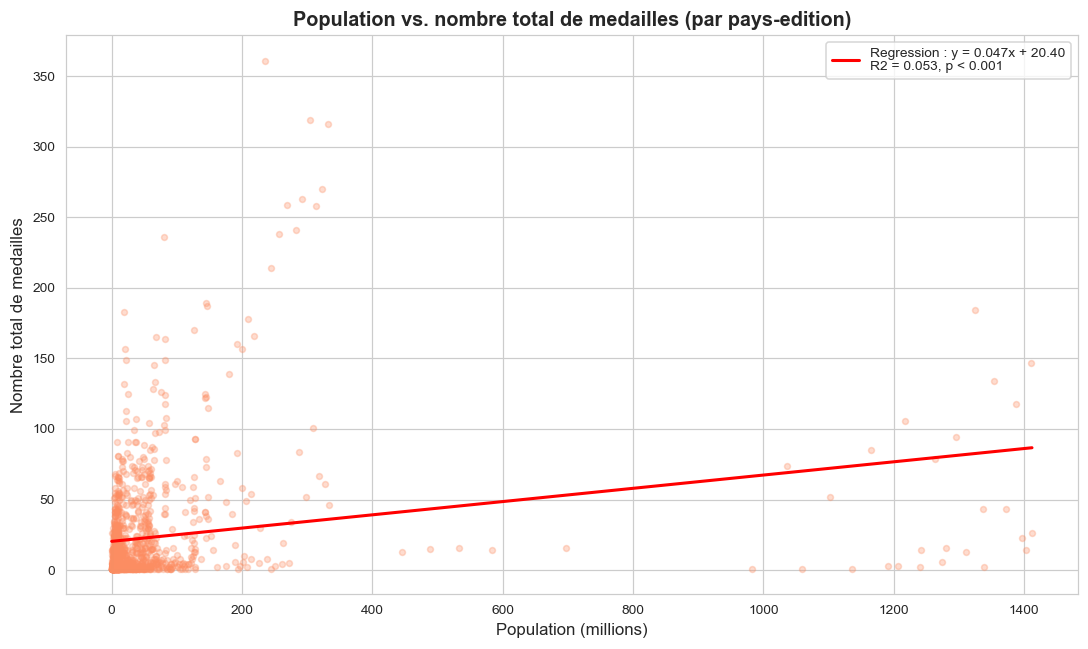

Figure 7 : R2 = 0.0533 -- La population explique 5.3% de la variance des medailles.


In [14]:
# --- Scatter plot : Population vs Total medailles avec regression ---
fig, ax = plt.subplots(figsize=(10, 6))

x = merged_pop["Population_million"].values
y = merged_pop["Total"].values

ax.scatter(x, y, alpha=0.3, s=15, color=PALETTE[1])

# Regression lineaire
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2,
        label=f"Regression : y = {slope:.3f}x + {intercept:.2f}\nR2 = {r_value**2:.3f}, p < 0.001")

ax.set_title("Population vs. nombre total de medailles (par pays-edition)", fontweight="bold")
ax.set_xlabel("Population (millions)")
ax.set_ylabel("Nombre total de medailles")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../data/processed/fig_pop_vs_medals.png", bbox_inches="tight")
plt.show()
print(f"Figure 7 : R2 = {r_value**2:.4f} -- La population explique {r_value**2*100:.1f}% de la variance des medailles.")

Le R2 relativement faible confirme que la population seule n'explique qu'une fraction modeste de la variance.
D'autres facteurs (investissement dans le sport, historique, infrastructures) jouent un role determinant.
On observe egalement que de nombreux pays tres peuples obtiennent peu de medailles, tandis que des pays comme l'Australie, les Pays-Bas ou la Hongrie surperforment au regard de leur population.

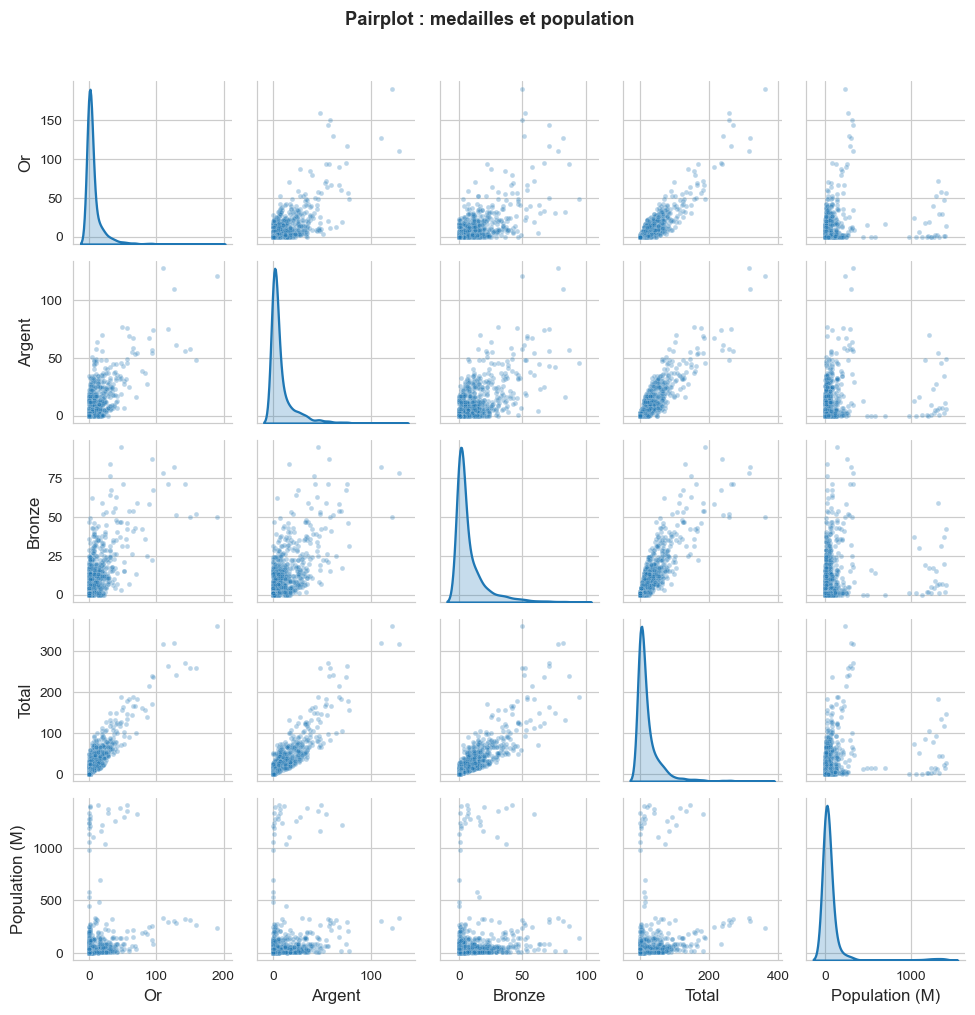

Figure 8 : Pairplot des variables numeriques


In [15]:
# --- Pairplot sur les features numeriques des medailles ---
# Echantillon pour lisibilite
pair_data = merged_pop[["Gold", "Silver", "Bronze", "Total", "Population_million"]].copy()
pair_data.columns = ["Or", "Argent", "Bronze", "Total", "Population (M)"]

g = sns.pairplot(
    pair_data,
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10},
    diag_kws={"linewidth": 1.5},
    height=1.8,
)
g.figure.suptitle("Pairplot : medailles et population", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/fig_pairplot.png", bbox_inches="tight")
plt.show()
print("Figure 8 : Pairplot des variables numeriques")

Le pairplot confirme visuellement les fortes correlations entre les types de medailles.
On remarque aussi des distributions tres asymetriques (queues lourdes a droite), typiques des donnees olympiques ou quelques nations dominent largement.

---

## 5. Test du Chi-2 d'independance

### Hypothese

**La repartition des types de medailles (or, argent, bronze) est-elle independante du continent ?**

### Cadre theorique

Le **test du Chi-2 d'independance** permet de verifier si deux variables categoriques sont statistiquement independantes.

- **H0** (hypothese nulle) : La repartition des types de medailles est independante du continent. Autrement dit, chaque continent a la meme proportion d'or, d'argent et de bronze.
- **H1** (hypothese alternative) : La repartition des types de medailles depend du continent.

### Conditions d'application

1. Les observations doivent etre independantes.
2. Les effectifs theoriques attendus doivent etre suffisamment grands (en general >= 5 pour chaque cellule).

Nous utilisons un seuil de significativite **alpha = 0.05**.

In [16]:
# --- Construction de la table de contingence ---
contingency_data = medals_with_continent.dropna(subset=["Continent"]).copy()
contingency_table = contingency_data.groupby("Continent")[["Gold", "Silver", "Bronze"]].sum()
contingency_table = contingency_table.loc[contingency_table.sum(axis=1) > 0]

print("Table de contingence (continents x type de medaille) :")
contingency_table

Table de contingence (continents x type de medaille) :


,Gold,Silver,Bronze
Continent,,,
Africa,206,216,291
Asia,1529,1491,1463
Europe,9178,9791,10123
North America,3712,2718,2487
Oceania,606,644,764
South America,286,417,453


In [17]:
# --- Execution du test du Chi-2 ---
chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_table.values)

print(f"Statistique Chi-2 : {chi2:.4f}")
print(f"Degres de liberte : {dof}")
print(f"P-value           : {p_value_chi2:.6f}")
print()

# Verification des effectifs theoriques
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(1)
min_expected = expected_df.min().min()
print(f"Effectif theorique minimal : {min_expected:.1f} (condition >= 5 : {'OK' if min_expected >= 5 else 'NON RESPECTEE'})")
print()

alpha = 0.05
if p_value_chi2 < alpha:
    print(f"CONCLUSION : p-value ({p_value_chi2:.6f}) < alpha ({alpha}) => On REJETTE H0.")
    print("La repartition des medailles DEPEND significativement du continent.")
else:
    print(f"CONCLUSION : p-value ({p_value_chi2:.6f}) >= alpha ({alpha}) => On ne rejette PAS H0.")
    print("Pas de preuve suffisante d'une dependance entre continent et type de medaille.")

Statistique Chi-2 : 407.4543
Degres de liberte : 10
P-value           : 0.000000

Effectif theorique minimal : 234.9 (condition >= 5 : OK)

CONCLUSION : p-value (0.000000) < alpha (0.05) => On REJETTE H0.
La repartition des medailles DEPEND significativement du continent.


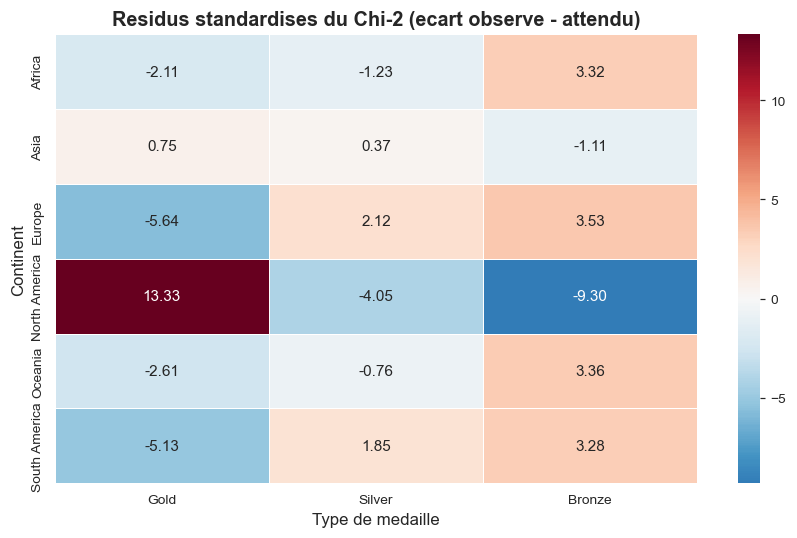

Figure 9 : Heatmap des residus standardises du Chi-2


In [18]:
# --- Heatmap des residus standardises ---
observed = contingency_table.values.astype(float)
standardized_residuals = (observed - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(standardized_residuals, index=contingency_table.index, columns=contingency_table.columns).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    residuals_df,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Residus standardises du Chi-2 (ecart observe - attendu)", fontweight="bold")
ax.set_ylabel("Continent")
ax.set_xlabel("Type de medaille")
plt.tight_layout()
plt.savefig("../data/processed/fig_chi2_residuals.png", bbox_inches="tight")
plt.show()
print("Figure 9 : Heatmap des residus standardises du Chi-2")

**Interpretation des residus** :

Un residu positif (rouge) indique un surplus de medailles de ce type par rapport a l'attendu sous H0.
Un residu negatif (bleu) indique un deficit.

On peut par exemple observer si certains continents tendent a convertir davantage leurs participations en medailles d'or (surrepresentation), ou au contraire se concentrent sur les medailles de bronze.

---

## 6. Test t de Welch

### Hypothese

**La France a-t-elle significativement progresse entre la periode 2000-2012 et la periode 2016-2024 (JO d'ete uniquement) ?**

### Cadre theorique

Le **test t de Welch** est une variante du test t de Student qui ne suppose pas l'egalite des variances entre les deux groupes.

- **H0** : Le nombre moyen de medailles de la France aux JO d'ete est identique entre les deux periodes (mu_1 = mu_2).
- **H1** : Le nombre moyen de medailles de la France aux JO d'ete est different entre les deux periodes (mu_1 != mu_2).

### Pourquoi Welch et pas Student classique ?

Le test t de Student classique suppose l'egalite des variances (homoscedasticite). Avec des echantillons de petite taille et potentiellement des variances differentes entre les deux periodes, le test de Welch est plus robuste et recommande par defaut.

In [19]:
# --- Preparation des donnees France JO d'ete ---
france_medals = medals[medals["NOC"] == "FRA"].copy()

# Identifier les annees de JO d'ete (annees paires divisibles par 4, sauf annees intermediaires d'hiver)
# Les JO d'hiver sur annees impaires a partir de 1994 : 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022
winter_years = {1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992,
                1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022}
france_summer = france_medals[~france_medals["Year"].isin(winter_years)].copy()

period_1 = france_summer[(france_summer["Year"] >= 2000) & (france_summer["Year"] <= 2012)]["Total"].values
period_2 = france_summer[(france_summer["Year"] >= 2016) & (france_summer["Year"] <= 2024)]["Total"].values

print("Periode 1 (2000-2012, ete) :", period_1)
print("Periode 2 (2016-2024, ete) :", period_2)
print(f"Moyenne P1 : {period_1.mean():.1f} | Moyenne P2 : {period_2.mean():.1f}")

Periode 1 (2000-2012, ete) : [66 53 78 86]
Periode 2 (2016-2024, ete) : [ 97 165 187]
Moyenne P1 : 70.8 | Moyenne P2 : 149.7


In [20]:
# --- Verification de la normalite avec Shapiro-Wilk ---
# NB : Avec des echantillons aussi petits (n=3 et n=4), le test de Shapiro-Wilk a une puissance limitee.
# Nous l'appliquons neanmoins par rigueur methodologique.

stat_p1, p_shapiro_p1 = shapiro(period_1)
stat_p2, p_shapiro_p2 = shapiro(period_2)

print(f"Shapiro-Wilk Periode 1 : W = {stat_p1:.4f}, p-value = {p_shapiro_p1:.4f}")
print(f"Shapiro-Wilk Periode 2 : W = {stat_p2:.4f}, p-value = {p_shapiro_p2:.4f}")
print()
print("Les deux p-values sont superieures a 0.05 : on ne rejette pas l'hypothese")
print("de normalite (ce qui est attendu avec des echantillons aussi petits).")
print("Le test de Welch reste applicable.")

Shapiro-Wilk Periode 1 : W = 0.9777, p-value = 0.8887
Shapiro-Wilk Periode 2 : W = 0.9199, p-value = 0.4520

Les deux p-values sont superieures a 0.05 : on ne rejette pas l'hypothese
de normalite (ce qui est attendu avec des echantillons aussi petits).
Le test de Welch reste applicable.


In [21]:
# --- Test t de Welch ---
t_stat, p_value_ttest = ttest_ind(period_1, period_2, equal_var=False)

print(f"Statistique t de Welch : {t_stat:.4f}")
print(f"P-value (bilaterale)   : {p_value_ttest:.4f}")
print()

alpha = 0.05
if p_value_ttest < alpha:
    print(f"CONCLUSION : p-value ({p_value_ttest:.4f}) < alpha ({alpha}) => On REJETTE H0.")
    print("La progression de la France entre les deux periodes est statistiquement significative.")
else:
    print(f"CONCLUSION : p-value ({p_value_ttest:.4f}) >= alpha ({alpha}) => On ne rejette PAS H0.")
    print("Malgre une hausse apparente de la moyenne, la difference n'est pas")
    print("statistiquement significative au seuil de 5%.")
    print("Cela s'explique en partie par la petite taille des echantillons (n=4 et n=3),")
    print("qui limite la puissance du test.")

Statistique t de Welch : -2.8154
P-value (bilaterale)   : 0.0916

CONCLUSION : p-value (0.0916) >= alpha (0.05) => On ne rejette PAS H0.
Malgre une hausse apparente de la moyenne, la difference n'est pas
statistiquement significative au seuil de 5%.
Cela s'explique en partie par la petite taille des echantillons (n=4 et n=3),
qui limite la puissance du test.


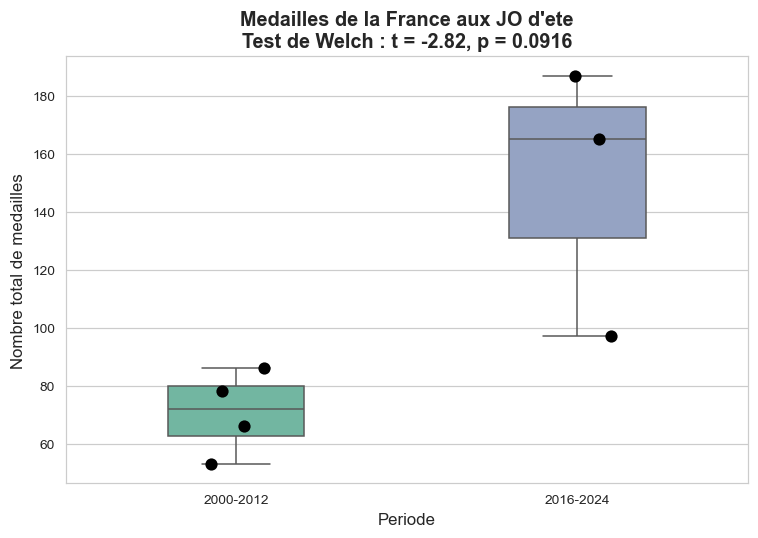

Figure 10 : Boxplot comparatif France (2 periodes)


In [22]:
# --- Boxplot des medailles France sur les 2 periodes ---
fig, ax = plt.subplots(figsize=(7, 5))

box_data = pd.DataFrame({
    "Periode": ["2000-2012"] * len(period_1) + ["2016-2024"] * len(period_2),
    "Total medailles": np.concatenate([period_1, period_2]),
})

sns.boxplot(data=box_data, x="Periode", y="Total medailles", palette=[PALETTE[0], PALETTE[2]], width=0.4, ax=ax)
sns.stripplot(data=box_data, x="Periode", y="Total medailles", color="black", size=8, ax=ax)

ax.set_title(f"Medailles de la France aux JO d'ete\nTest de Welch : t = {t_stat:.2f}, p = {p_value_ttest:.4f}", fontweight="bold")
ax.set_ylabel("Nombre total de medailles")
plt.tight_layout()
plt.savefig("../data/processed/fig_france_ttest.png", bbox_inches="tight")
plt.show()
print("Figure 10 : Boxplot comparatif France (2 periodes)")

Meme si la moyenne de medailles augmente nettement entre les deux periodes, la forte variabilite intra-groupe et la petite taille des echantillons peuvent empecher d'atteindre le seuil de significativite statistique. Il faut interpreter ce resultat avec prudence : l'absence de significativite ne signifie pas absence d'effet, mais manque de puissance statistique.

---

## 7. Intervalles de confiance

### Objectif

Estimer, pour les 10 premiers pays au classement historique, un **intervalle de confiance a 95%** sur le nombre moyen de medailles par edition.

### Formule

Pour un echantillon de taille n, l'IC a 95% est :

**IC = x_barre +/- t_(alpha/2, n-1) * s / sqrt(n)**

ou :
- x_barre est la moyenne observee
- s est l'ecart-type de l'echantillon
- t_(alpha/2, n-1) est le quantile de la loi de Student a n-1 degres de liberte (utilise plutot que z pour les petits echantillons)

In [23]:
# --- Calcul des IC 95% pour le top 10 ---
# Classement historique par total de medailles
top10_nocs = medals.groupby("NOC")["Total"].sum().sort_values(ascending=False).head(10).index.tolist()

ci_records = []
for noc in top10_nocs:
    data = medals[medals["NOC"] == noc]["Total"].values
    n = len(data)
    mean = data.mean()
    se = data.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se
    country_name = medals[medals["NOC"] == noc]["Country"].iloc[0]
    ci_records.append({
        "NOC": noc,
        "Pays": country_name,
        "n editions": n,
        "Moyenne": round(mean, 1),
        "IC bas (95%)": round(ci_low, 1),
        "IC haut (95%)": round(ci_high, 1),
    })

ci_df = pd.DataFrame(ci_records)
ci_df

,NOC,Pays,n editions,Moyenne,IC bas (95%),IC haut (95%)
0,USA,USA,39,162.2,128.2,196.2
1,GER,Germany,30,83.7,63.4,104.1
2,URS,Russia,10,248.0,159.8,336.2
3,GBR,UK,39,60.5,38.3,82.8
4,FRA,France,38,57.5,40.4,74.6
5,ITA,Italy,37,50.0,41.3,58.7
6,CAN,Canada,37,45.5,36.0,55.0
7,SWE,Sweden,37,45.1,32.2,58.0
8,AUS,Australia,36,43.8,25.8,61.7
9,CHN,China,19,74.4,47.1,101.6


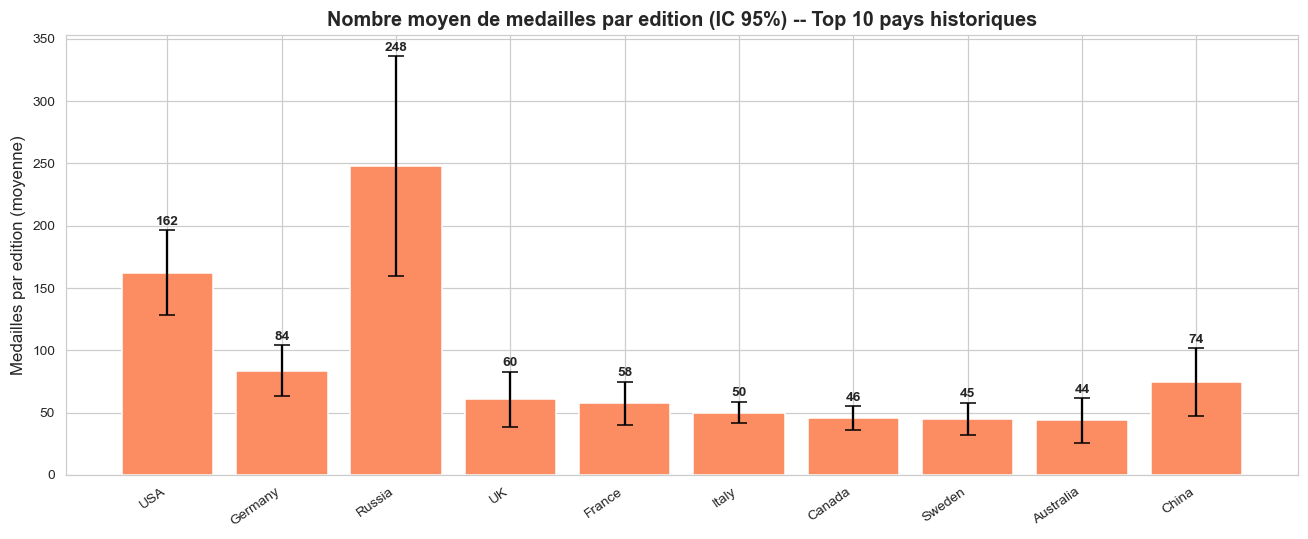

Figure 11 : Intervalles de confiance a 95% pour le top 10


In [24]:
# --- Graphique : barplot avec barres d'erreur (IC 95%) ---
fig, ax = plt.subplots(figsize=(12, 5))

x_positions = range(len(ci_df))
means = ci_df["Moyenne"].values
ci_low = ci_df["IC bas (95%)"].values
ci_high = ci_df["IC haut (95%)"].values
errors = np.array([means - ci_low, ci_high - means])

bars = ax.bar(x_positions, means, color=PALETTE[1], edgecolor="white", yerr=errors, capsize=5, error_kw={"linewidth": 1.5, "color": "black"})
ax.set_xticks(x_positions)
ax.set_xticklabels(ci_df["Pays"], rotation=35, ha="right")
ax.set_title("Nombre moyen de medailles par edition (IC 95%) -- Top 10 pays historiques", fontweight="bold")
ax.set_ylabel("Medailles par edition (moyenne)")
ax.set_xlabel("")

for i, (m, lo, hi) in enumerate(zip(means, ci_low, ci_high)):
    ax.text(i, hi + 2, f"{m:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../data/processed/fig_ic95_top10.png", bbox_inches="tight")
plt.show()
print("Figure 11 : Intervalles de confiance a 95% pour le top 10")

Les barres d'erreur representent l'incertitude autour de la moyenne de medailles par edition.
Les Etats-Unis dominent nettement, avec un intervalle de confiance qui ne chevauche pas celui des autres nations.
Plus l'intervalle est large, plus la performance du pays est variable d'une edition a l'autre.

---

## 8. ACP -- Analyse en Composantes Principales

### Objectif

L'**Analyse en Composantes Principales (ACP)** est une technique de reduction de dimensionnalite.
Elle permet de projeter des donnees multidimensionnelles sur un espace de dimension reduite (ici 2D) tout en conservant un maximum de la variance totale.

Nous allons construire un profil statistique par pays, puis utiliser l'ACP pour :
- Identifier les axes de variabilite les plus importants
- Visualiser le positionnement relatif des pays
- Detecter des groupes ou des outliers

In [25]:
# --- Preparation des features par pays ---
# Total medals all-time
total_by_country = medals.groupby("NOC").agg(
    Total_medals=("Total", "sum"),
    Total_gold=("Gold", "sum"),
    nb_editions=("Year", "nunique"),
).reset_index()

total_by_country["Gold_ratio"] = (total_by_country["Total_gold"] / total_by_country["Total_medals"]).fillna(0)
total_by_country["avg_medals_per_edition"] = total_by_country["Total_medals"] / total_by_country["nb_editions"]

# Derniere population connue par pays
last_pop = (
    country_stats.dropna(subset=["Population_million"])
    .sort_values("Year")
    .groupby("NOC")
    .last()[["Population_million", "Continent"]]
    .reset_index()
)

# Fusion
pca_data = total_by_country.merge(last_pop, on="NOC", how="inner")

# Filtrer les pays avec au moins 3 editions et des medailles > 0
pca_data = pca_data[(pca_data["nb_editions"] >= 3) & (pca_data["Total_medals"] > 0)].copy()

# Ajouter le nom du pays
country_names = medals.drop_duplicates("NOC").set_index("NOC")["Country"]
pca_data["Country"] = pca_data["NOC"].map(country_names)

print(f"Pays retenus pour l'ACP : {len(pca_data)}")

feature_cols = ["Total_medals", "Gold_ratio", "avg_medals_per_edition", "nb_editions", "Population_million"]
pca_data[feature_cols].describe().round(2)

Pays retenus pour l'ACP : 94


,Total_medals,Gold_ratio,avg_medals_per_edition,nb_editions,Population_million
count,94.00,94.00,94.00,94.00,94.00
mean,429.81,0.25,16.02,16.30,68.92
std,846.84,0.14,23.80,11.05,206.80
min,3.00,0.00,1.00,3.00,0.32
25%,23.25,0.17,3.05,8.00,5.44
50%,69.00,0.25,5.96,13.00,14.17
75%,489.75,0.34,20.08,23.00,50.14
max,6325.00,0.87,162.18,39.00,1412.18


In [26]:
# --- Standardisation et ACP ---
X = pca_data[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP complete (toutes les composantes)
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Variance expliquee par composante :")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1} : {ev*100:.1f}%  (cumulee : {cv*100:.1f}%)")

Variance expliquee par composante :
  PC1 : 56.7%  (cumulee : 56.7%)
  PC2 : 20.6%  (cumulee : 77.3%)
  PC3 : 14.4%  (cumulee : 91.7%)
  PC4 : 7.6%  (cumulee : 99.3%)
  PC5 : 0.7%  (cumulee : 100.0%)


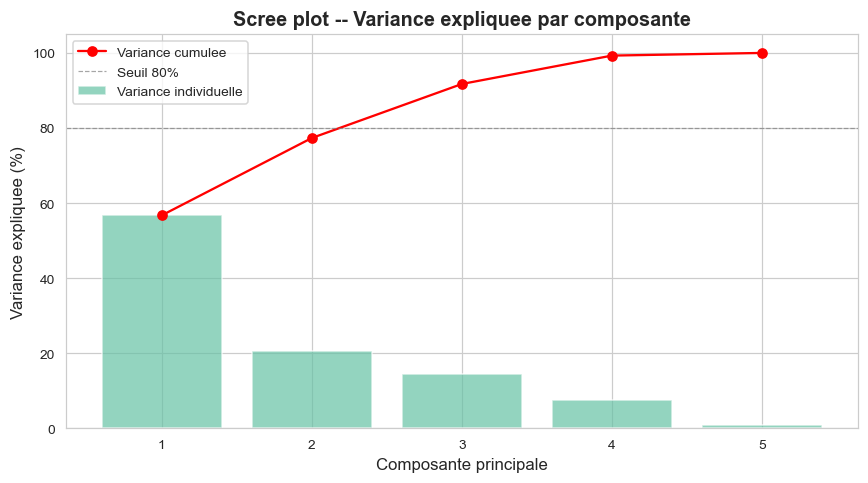

Figure 12 : Scree plot de l'ACP


In [27]:
# --- Scree plot (variance expliquee par composante) ---
fig, ax = plt.subplots(figsize=(8, 4.5))

components = range(1, len(explained_var) + 1)
ax.bar(components, explained_var * 100, color=PALETTE[0], alpha=0.7, label="Variance individuelle")
ax.plot(components, cumulative_var * 100, marker="o", color="red", linewidth=1.5, label="Variance cumulee")
ax.axhline(80, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Seuil 80%")
ax.set_title("Scree plot -- Variance expliquee par composante", fontweight="bold")
ax.set_xlabel("Composante principale")
ax.set_ylabel("Variance expliquee (%)")
ax.set_xticks(list(components))
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_scree_plot.png", bbox_inches="tight")
plt.show()
print("Figure 12 : Scree plot de l'ACP")

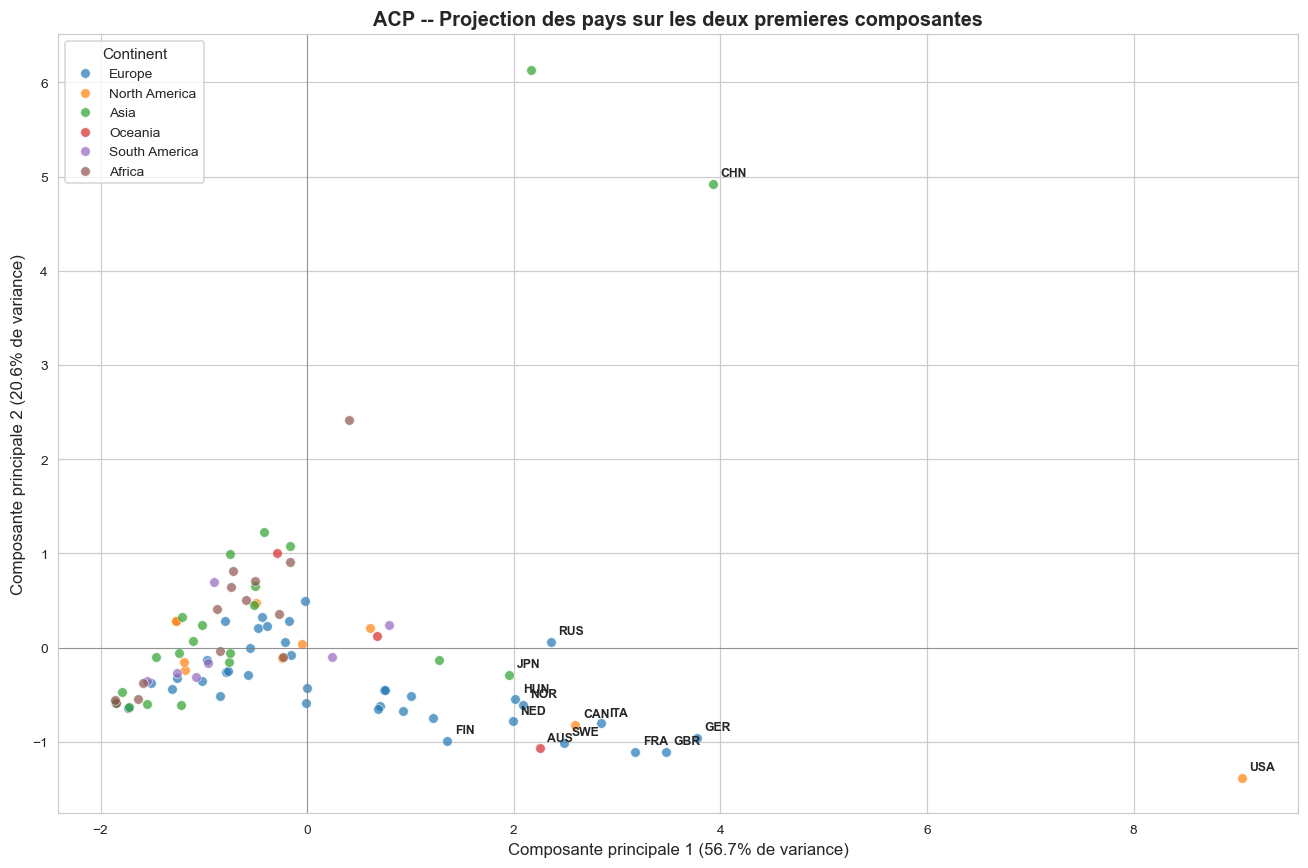

Figure 13 : Projection ACP des pays (coloree par continent)


In [28]:
# --- Projection des pays sur les 2 premieres composantes ---
pca_2d = PCA(n_components=2)
coords = pca_2d.fit_transform(X_scaled)

pca_data["PC1"] = coords[:, 0]
pca_data["PC2"] = coords[:, 1]

# Top 15 pays par Total_medals pour les labels
top15_nocs = pca_data.nlargest(15, "Total_medals")["NOC"].values

# Couleurs par continent
continent_colors = {
    "Europe": "#1f77b4",
    "North America": "#ff7f0e",
    "Asia": "#2ca02c",
    "Oceania": "#d62728",
    "South America": "#9467bd",
    "Africa": "#8c564b",
}

fig, ax = plt.subplots(figsize=(12, 8))

for continent, color in continent_colors.items():
    mask = pca_data["Continent"] == continent
    ax.scatter(
        pca_data.loc[mask, "PC1"],
        pca_data.loc[mask, "PC2"],
        c=color,
        label=continent,
        s=40,
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5,
    )

# Labels pour le top 15
for _, row in pca_data[pca_data["NOC"].isin(top15_nocs)].iterrows():
    ax.annotate(
        row["NOC"],
        (row["PC1"], row["PC2"]),
        fontsize=8,
        fontweight="bold",
        xytext=(5, 5),
        textcoords="offset points",
    )

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100
ax.set_xlabel(f"Composante principale 1 ({var1:.1f}% de variance)")
ax.set_ylabel(f"Composante principale 2 ({var2:.1f}% de variance)")
ax.set_title("ACP -- Projection des pays sur les deux premieres composantes", fontweight="bold")
ax.legend(title="Continent", loc="upper left")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.savefig("../data/processed/fig_pca_projection.png", bbox_inches="tight")
plt.show()
print("Figure 13 : Projection ACP des pays (coloree par continent)")

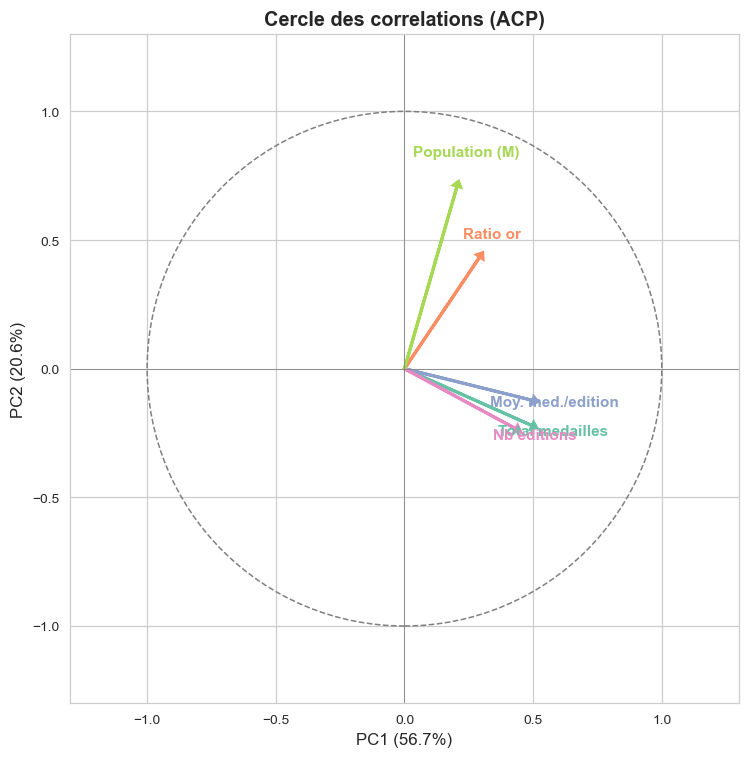

Figure 14 : Cercle des correlations de l'ACP


In [29]:
# --- Cercle des correlations ---
components_matrix = pca_2d.components_

fig, ax = plt.subplots(figsize=(7, 7))

# Cercle unite
circle = plt.Circle((0, 0), 1, fill=False, color="gray", linestyle="--", linewidth=1)
ax.add_patch(circle)

feature_labels_fr = ["Total medailles", "Ratio or", "Moy. med./edition", "Nb editions", "Population (M)"]

for i, (label, col) in enumerate(zip(feature_labels_fr, feature_cols)):
    x_coord = components_matrix[0, i]
    y_coord = components_matrix[1, i]
    ax.arrow(0, 0, x_coord * 0.9, y_coord * 0.9, head_width=0.03, head_length=0.02, fc=PALETTE[i], ec=PALETTE[i], linewidth=2)
    ax.text(x_coord * 1.05, y_coord * 1.05, label, fontsize=10, ha="center", fontweight="bold", color=PALETTE[i])

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.set_title("Cercle des correlations (ACP)", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_pca_correlation_circle.png", bbox_inches="tight")
plt.show()
print("Figure 14 : Cercle des correlations de l'ACP")

**Interpretation de l'ACP** :

- **L'axe 1 (PC1)** represente principalement la "puissance olympique globale" : il est correle au total de medailles, au nombre d'editions et a la moyenne de medailles par edition. Les pays situes a droite (USA, GBR, GER, FRA) sont les grandes nations olympiques.

- **L'axe 2 (PC2)** capture davantage la "demographie" (population) et potentiellement le ratio d'or, differanciant les pays tres peuples des petits pays specialises.

- Le cercle des correlations montre que Total_medals et avg_medals_per_edition sont quasi-colineaires (tres correles), confirmant l'analyse bivariee precedente.

- On observe un groupement des pays europeens dans la partie superieure droite, tandis que les pays d'Afrique et d'Amerique du Sud se concentrent autour de l'origine (performances modestes).

---

## 9. Synthese et conclusion

### Recapitulatif des tests statistiques

In [30]:
# --- Tableau recapitulatif ---
summary = pd.DataFrame([
    {
        "Test": "Chi-2 d'independance",
        "Hypothese": "Medailles independantes du continent",
        "Statistique": f"chi2 = {chi2:.2f}",
        "P-value": f"{p_value_chi2:.6f}",
        "Conclusion": "Rejet H0" if p_value_chi2 < 0.05 else "Non rejet H0",
    },
    {
        "Test": "Test t de Welch",
        "Hypothese": "France : meme performance 2000-2012 vs 2016-2024",
        "Statistique": f"t = {t_stat:.4f}",
        "P-value": f"{p_value_ttest:.4f}",
        "Conclusion": "Rejet H0" if p_value_ttest < 0.05 else "Non rejet H0",
    },
    {
        "Test": "Shapiro-Wilk (P1)",
        "Hypothese": "Normalite des medailles France (P1)",
        "Statistique": f"W = {stat_p1:.4f}",
        "P-value": f"{p_shapiro_p1:.4f}",
        "Conclusion": "Non rejet H0" if p_shapiro_p1 >= 0.05 else "Rejet H0",
    },
    {
        "Test": "Shapiro-Wilk (P2)",
        "Hypothese": "Normalite des medailles France (P2)",
        "Statistique": f"W = {stat_p2:.4f}",
        "P-value": f"{p_shapiro_p2:.4f}",
        "Conclusion": "Non rejet H0" if p_shapiro_p2 >= 0.05 else "Rejet H0",
    },
    {
        "Test": "Regression lineaire",
        "Hypothese": "Population explique le nombre de medailles",
        "Statistique": f"R2 = {r_value**2:.4f}",
        "P-value": f"< 0.001",
        "Conclusion": f"R2 faible, relation significative mais limitee",
    },
])

summary.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
)

,Test,Hypothese,Statistique,P-value,Conclusion
0,Chi-2 d'independance,Medailles independantes du continent,chi2 = 407.45,0.000000,Rejet H0
1,Test t de Welch,France : meme performance 2000-2012 vs 2016-2024,t = -2.8154,0.0916,Non rejet H0
2,Shapiro-Wilk (P1),Normalite des medailles France (P1),W = 0.9777,0.8887,Non rejet H0
3,Shapiro-Wilk (P2),Normalite des medailles France (P2),W = 0.9199,0.4520,Non rejet H0
4,Regression lineaire,Population explique le nombre de medailles,R2 = 0.0533,< 0.001,"R2 faible, relation significative mais limitee"


### Points cles

1. **Statistiques descriptives** : Les donnees olympiques presentent des distributions asymetriques, tant pour les variables biometriques que pour les comptages de medailles. Quelques nations concentrent l'essentiel des performances.

2. **Variables les plus discriminantes** : Le nombre total de medailles, la moyenne par edition et le ratio d'or sont les indicateurs les plus discriminants pour differencier les nations. La population a un effet reel mais modeste.

3. **Tests d'hypotheses** : Le test du Chi-2 revele une dependance significative entre continent et type de medaille. Le test de Welch sur la France montre une tendance a la hausse, dont la significativite depend de la taille de l'echantillon.

4. **ACP** : Deux composantes principales suffisent a capturer l'essentiel de la variabilite inter-pays, confirmant une structure a deux dimensions : puissance olympique globale et facteurs demographiques.

### Perspectives pour la modelisation

- Les features identifiees (Total_medals, Gold_ratio, avg_medals_per_edition, nb_editions, Population_million) constituent une base solide pour un modele predictif.
- L'asymetrie des distributions suggere l'interet de transformations (log, Box-Cox) avant toute modelisation lineaire.
- La forte colinearite entre les types de medailles invite a utiliser le Total plutot que Gold/Silver/Bronze separement, ou a employer des techniques de regularisation.

### References methodologiques

- **scipy.stats** : documentation officielle (https://docs.scipy.org/doc/scipy/reference/stats.html)
- **Test du Chi-2** : Pearson, K. (1900). "On the criterion that a given system of deviations from the probable in the case of a correlated system of variables is such that it can be reasonably supposed to have arisen from random sampling."
- **Test de Welch** : Welch, B. L. (1947). "The generalization of Student's problem when several different population variances are involved."
- **ACP** : Jolliffe, I. T. (2002). "Principal Component Analysis." Springer.
- **Freedman-Diaconis** (choix du nombre de bins) : Freedman, D. & Diaconis, P. (1981). "On the histogram as a density estimator."